In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set aesthetic style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("✅ Library Loaded: Siap melakukan audit data Gacoan.")

✅ Library Loaded: Siap melakukan audit data Gacoan.


In [7]:
# Load data dari file CSV yang kamu buat saat observasi
try:
    df_trx = pd.read_csv('gacoan_transactions.csv')
    df_turnover = pd.read_csv('gacoan_table_turnover.csv')
    print("✅ Raw Data Suhat Terdeteksi.")
except:
    print("❌ File tidak ditemukan. Pastikan file CSV ada di folder yang sama.")

✅ Raw Data Suhat Terdeteksi.


In [8]:
# 1. Hitung GMV & Estimated Profit (KPI Utama Gacoan)
# Food Cost di F&B rata-rata 40%, Margin 60%
df_trx['food_cost'] = df_trx['total_net'] * 0.4
df_trx['gross_profit'] = df_trx['total_net'] * 0.6

# 2. Hitung Average Transaction Value (ATV)
atv = df_trx.groupby('trx_id')['total_net'].sum().mean()

# 3. Analisis Kecepatan Meja (Operational Efficiency)
# Bersihkan data dwell time
df_turnover['dwell_time_min'] = pd.to_numeric(df_turnover['dwell_time_min'], errors='coerce')
avg_dwell = df_turnover[df_turnover['status'] == 'Completed']['dwell_time_min'].mean()

print(f"📊 KPI SUMMARY - Gacoan Suhat")
print(f"Total Revenue: Rp {df_trx['total_net'].sum():,.0f}")
print(f"Average Guest Spending (ATV): Rp {atv:,.0f}")
print(f"Avg Table Turnover: {avg_dwell:.1f} Minutes")

📊 KPI SUMMARY - Gacoan Suhat
Total Revenue: Rp 134
Average Guest Spending (ATV): Rp 27
Avg Table Turnover: 56.3 Minutes


In [9]:
# Simulasi Query Cost Optimization (Requirements: SQL Optimization)
# Daripada scan seluruh tabel, kita filter kategori 'Mie' dulu baru hitung profit

mie_performance = (
    df_trx[df_trx['category'] == 'Mie'] # Filtering Early (Optimized)
    .groupby('item_name')
    .agg({'qty': 'sum', 'total_net': 'sum'})
    .sort_values('total_net', ascending=False)
)

print("⚡ SQL Optimized View: Performa Kategori Mie")
print(mie_performance)

⚡ SQL Optimized View: Performa Kategori Mie
                 qty  total_net
item_name                      
Mie Gacoan Lv 8    2      21.82
Mie Gacoan Lv 1    1      10.91
Mie Hompimpa       1      10.91


/var/folders/tv/sf8cb4t91619ww6c4k2ch47c0000gn/T/ipykernel_35231/3345126169.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=category_analysis, x='category', y='gross_profit', palette='viridis')


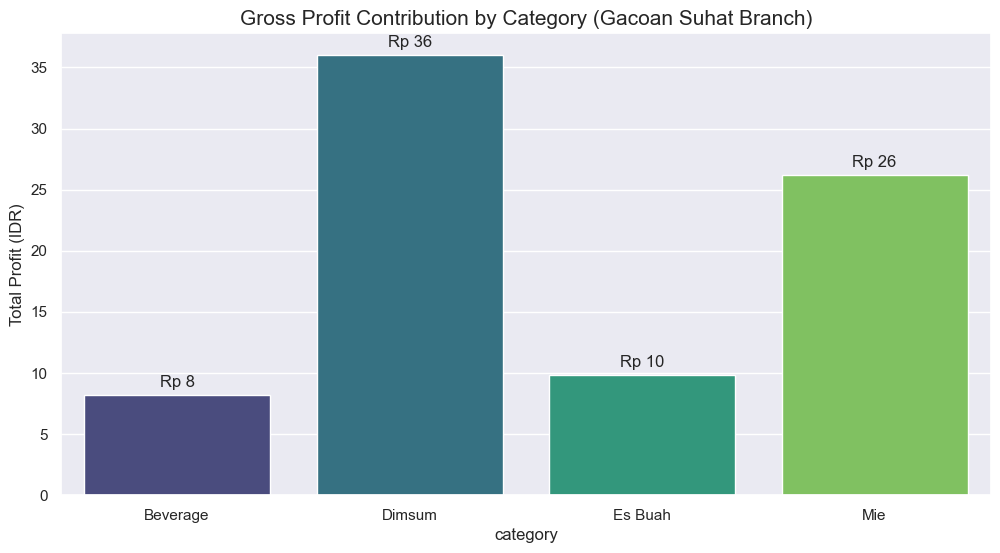

In [10]:
# Visualisasi Kontribusi Kategori terhadap Profit
category_analysis = df_trx.groupby('category')['gross_profit'].sum().reset_index()

plt.figure(figsize=(12, 6))
plot = sns.barplot(data=category_analysis, x='category', y='gross_profit', palette='viridis')

# Tambahkan label rupiah di atas bar
for p in plot.patches:
    plot.annotate(f'Rp {p.get_height():,.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Gross Profit Contribution by Category (Gacoan Suhat Branch)', fontsize=15)
plt.ylabel('Total Profit (IDR)')
plt.show()